In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv', sep='\t')
print(df.head())
print(df.info())
print(df['target'].value_counts())  # Check class balance

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

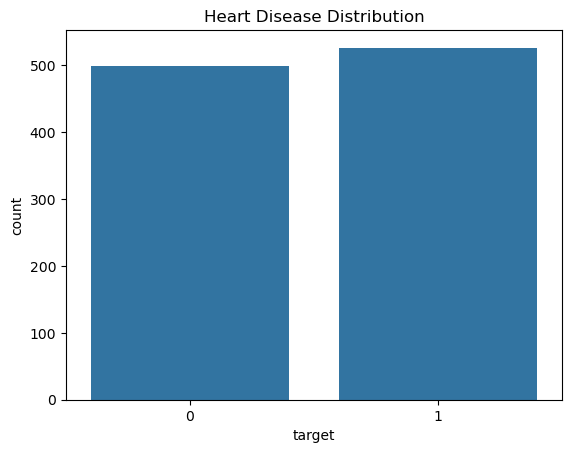

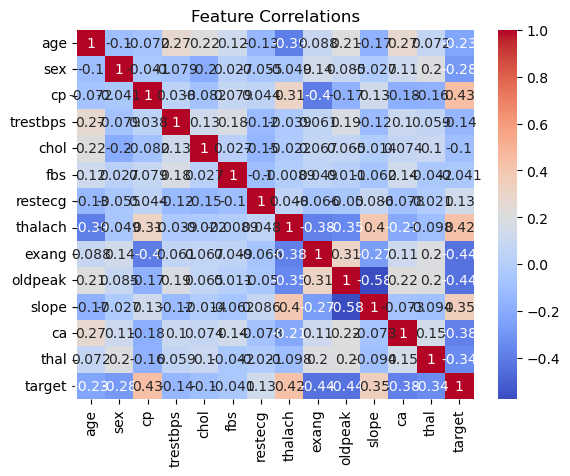

In [4]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()


In [6]:
df.replace('?', np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f"Logistic: {accuracy_score(y_test, lr_pred):.3f}")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest: {accuracy_score(y_test, rf_pred):.3f}")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print(f"KNN: {accuracy_score(y_test, knn_pred):.3f}")


Logistic: 0.795
Random Forest: 0.985
KNN: 0.834


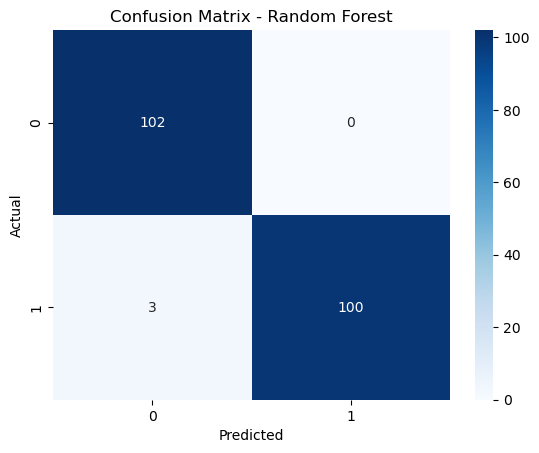

In [10]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [11]:
new_patient = np.array([[55, 1, 0, 140, 250, 1, 0, 160, 0, 2.0, 2, 0, 3]])  # Example values
new_patient_scaled = scaler.transform(new_patient)
prediction = rf.predict(new_patient_scaled)
print("Heart Disease Risk:", "High" if prediction[0] == 1 else "Low")


Heart Disease Risk: High


c:\Users\mohansai\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
